Files already downloaded and verified
Files already downloaded and verified

--- Running for patch size 2 ---
Epoch 1: Loss=1.7662, Accuracy=0.4825
Epoch 2: Loss=1.3355, Accuracy=0.5455
Epoch 3: Loss=1.1595, Accuracy=0.5780
Epoch 4: Loss=1.0309, Accuracy=0.5942
Epoch 5: Loss=0.9274, Accuracy=0.6253
Epoch 6: Loss=0.8301, Accuracy=0.6276
Epoch 7: Loss=0.7398, Accuracy=0.6283
Epoch 8: Loss=0.6375, Accuracy=0.6386
Epoch 9: Loss=0.5436, Accuracy=0.6349
Epoch 10: Loss=0.4266, Accuracy=0.6233
Epoch 11: Loss=0.3397, Accuracy=0.6316
Epoch 12: Loss=0.2652, Accuracy=0.6268
Epoch 13: Loss=0.2023, Accuracy=0.6195
Epoch 14: Loss=0.1527, Accuracy=0.6156
Epoch 15: Loss=0.1362, Accuracy=0.6183

--- Running for patch size 4 ---
Epoch 1: Loss=1.6989, Accuracy=0.4885
Epoch 2: Loss=1.3053, Accuracy=0.5608
Epoch 3: Loss=1.1441, Accuracy=0.5856
Epoch 4: Loss=1.0179, Accuracy=0.6049
Epoch 5: Loss=0.9150, Accuracy=0.6247
Epoch 6: Loss=0.8123, Accuracy=0.6321
Epoch 7: Loss=0.7013, Accuracy=0.6291
Epoch 8: Loss=

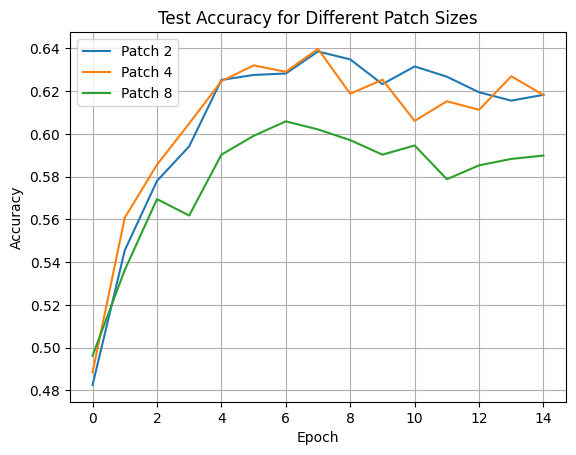

Patch Size 2: Final Accuracy = 0.6183
Patch Size 4: Final Accuracy = 0.6182
Patch Size 8: Final Accuracy = 0.5899


In [1]:
# Vision Transformer (ViT) for CIFAR-10 based on "An Image is Worth 16x16 Words"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


# -------------------------------
# Patch Embedding
# -------------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels=3, emb_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # shape: [B, emb_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)  # shape: [B, N_patches, emb_dim]
        return x


# -------------------------------
# Multi-Head Self-Attention
# -------------------------------
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.heads = heads
        self.head_dim = dim // heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.out = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # shape: [B, heads, N, head_dim]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.out(out)


# -------------------------------
# Transformer Encoder Block
# -------------------------------
class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# -------------------------------
# Vision Transformer
# -------------------------------
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=256, depth=6, heads=8, mlp_dim=512, n_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, emb_dim=emb_dim)
        num_patches = (img_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(emb_dim, heads, mlp_dim) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        B, N, _ = x.shape
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed[:, :N+1]
        x = self.encoder(x)
        x = self.norm(x[:, 0])  # Use CLS token
        return self.head(x)


# -------------------------------
# Training and Evaluation
# -------------------------------
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


# -------------------------------
# Run Patch Size Variation
# -------------------------------
def run_patch_size_experiments():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

    patch_sizes = [2, 4, 8]
    results = {}

    for patch_size in patch_sizes:
        print(f"\n--- Running for patch size {patch_size} ---")
        model = VisionTransformer(patch_size=patch_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
        criterion = nn.CrossEntropyLoss()

        losses, accs = [], []
        for epoch in range(15):
            loss = train(model, trainloader, optimizer, criterion, device)
            acc = evaluate(model, testloader, device)
            losses.append(loss)
            accs.append(acc)
            print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

        results[patch_size] = (losses, accs)
        plt.plot(accs, label=f'Patch {patch_size}')

    plt.title("Test Accuracy for Different Patch Sizes")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig("vit_patch_accuracy.png")
    plt.show()

    for patch_size in patch_sizes:
        print(f"Patch Size {patch_size}: Final Accuracy = {results[patch_size][1][-1]:.4f}")


# Run patch size experiments
if __name__ == '__main__':
    run_patch_size_experiments()

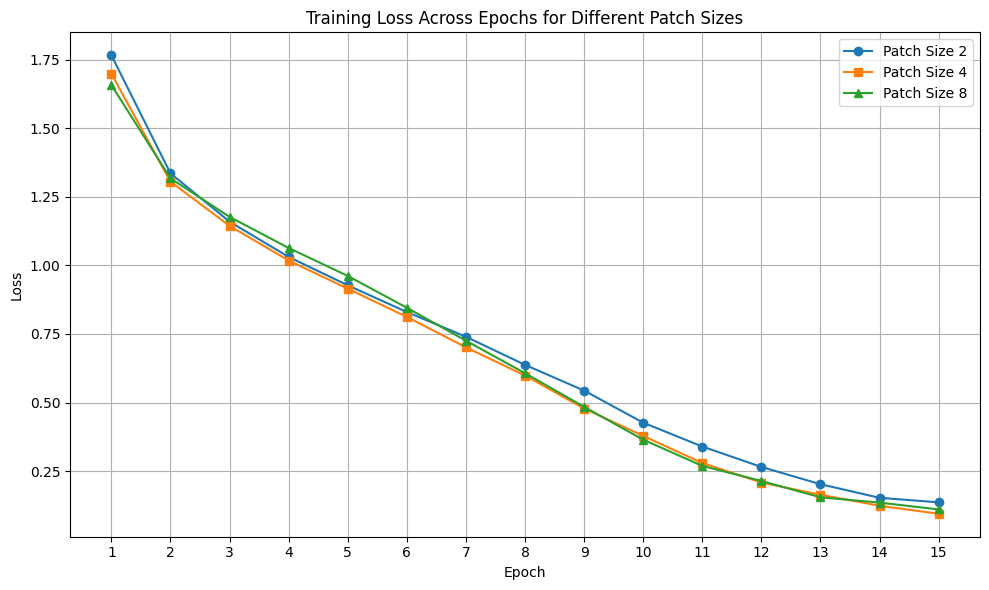

## Test Accuracies (After 15 Epochs)

- **Patch Size 2:** 61.83%  
- **Patch Size 4:** 61.82%  
- **Patch Size 8:** 58.99%  

---

## Analysis

The results show that smaller patch sizes (**2 and 4**) performed similarly, both achieving approximately **62% accuracy**, while **patch size 8** lagged behind at around **59%**.

This suggests that for **CIFAR-10's small 32×32 images**, using larger patches leads to a **loss of spatial information**. With **patch size 8**, the model only processes **16 patches** (4×4 grid), which appears insufficient to capture the **fine-grained details** needed for accurate classification.

The closer performance between **patch sizes 2 and 4** indicates a good balance between **computational efficiency** and **information retention**, with **patch size 4** being more **parameter-efficient** while maintaining similar performance.
